In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

from geomstats.geometry.poincare_half_space import PoincareHalfSpace

import matplotlib.pyplot as plt

from scipy.linalg import norm

import autograd.numpy as anp

import pymanopt
from pymanopt.manifolds import SymmetricPositiveDefinite
from pymanopt import Problem
from pymanopt.solvers import ConjugateGradient

import pdb

INFO: Using numpy backend


In [3]:
manifold = PoincareHalfSpace(2)
point = manifold.random_point()
base_point = manifold.random_point()
print('Base point : ', base_point)
print('Random point : ', point)
d = manifold.metric.dist(base_point, point)
print('Distance : ', d)


Base point :  [1.31528941 1.43486536]
Random point :  [0.49468848 0.74762624]
Distance :  0.9922311835295652


In [4]:
def get_metric_tensor(a,b):
    manifold = SymmetricPositiveDefinite(2)
    x_prime = (a-b).reshape(2,1)

    @pymanopt.function.Autograd
    def cost(M):
        lhs = x_prime.T@M@x_prime
        rhs = d**2
        loss = (lhs-rhs).squeeze()
        return loss

    problem = Problem(manifold=manifold, cost=cost, verbosity=0)
    solver = ConjugateGradient(logverbosity=0, maxiter=1e4)
    Mopt = solver.solve(problem, x=np.eye(2)+1e-10)
    
    return Mopt


In [7]:
eig_spectrum = np.zeros((10,2))
for i, mu in enumerate(np.linspace(-1,1,10)):
    a = np.asarray([i,0.5])
    b = np.asarray([0,0.5])
    M = get_metric_tensor(a,b)
    eigs,_ = np.linalg.eigh(M)
    eig_spectrum[i,:] = eigs

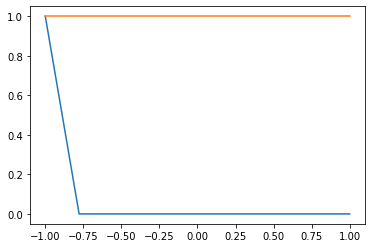

In [9]:
plt.plot(np.linspace(-1,1,10), eig_spectrum[:,0])
plt.plot(np.linspace(-1,1,10), eig_spectrum[:,1])
plt.show()

In [ ]:
sigma2 = base_point[-1]**2
M_true = np.eye(2,2)*(1/sigma2)
d_true = np.sqrt(x_prime.T@M_true@x_prime)
print('M expected : \n', M_true, '\nd expected : ', d_true)